# 실습 1. 전처리 데이터 불러오기

해야 할 일
 
먼저 Chapter 01에서 만든 CSV 파일을 pandas로 불러옵니다.

처음부터 단어를 분리하지 말고 데이터가 정상적으로 연결되는지 먼저 확인합니다.

In [1]:
import pandas as pd

# CSV 파일 불러오기
df_books = pd.read_csv("book_bestseller_clean.csv", encoding="utf-8-sig")

# 1. 전체 행과 컬럼 개수
print("전체 행과 컬럼 개수:", df_books.shape)

# 2. 컬럼 이름
print("\n컬럼 이름:")
print(df_books.columns)

# 3. 앞의 5행
print("\n앞의 5행:")
display(df_books.head())

# 4. '상품명' 컬럼이 존재하는지 확인
print("\n'상품명' 컬럼 존재 여부:")
print("상품명" in df_books.columns)

전체 행과 컬럼 개수: (199, 8)

컬럼 이름:
Index(['순위', '판매상품ID', '상품명', '판매가', '저자', '출판사', '발행일', '분야'], dtype='str')

앞의 5행:


,순위,판매상품ID,상품명,판매가,저자,출판사,발행일,분야
0,1,S000000610612,소년이 온다,13500,한강,창비,2014-05-19,소설
1,2,S000001632467,모순,11700,양귀자,쓰다,2013-04-01,소설
2,3,S000216262757,결국 국민이 합니다,19800,이재명,오마이북,2025-04-15,정치/사회
3,4,S000216111714,혼모노,16200,성해나,창비,2025-03-28,소설
4,5,S000200550189,급류,12600,정대건,민음사,2022-12-22,소설



'상품명' 컬럼 존재 여부:
True


### 실행 결과 요약

- `book_bestseller_clean.csv` 파일을 `df_books` DataFrame으로 정상적으로 불러왔다.
- 전체 데이터 크기는 **199행, 8개 컬럼**으로 확인되었다.
- 컬럼은 다음과 같이 구성되어 있다.

`순위`, `판매상품ID`, `상품명`, `판매가`, `저자`, `출판사`, `발행일`, `분야`

- `df_books.head()`를 사용하여 앞의 5행이 정상적으로 출력되는 것을 확인했다.
- `"상품명" in df_books.columns` 결과가 **True**로 출력되어 `상품명` 컬럼이 존재하는 것을 확인했다.

### 확인 결과

```text
전체 행과 컬럼 개수: (199, 8)
상품명 컬럼 존재 여부: True

# 실습 2. 분석할 도서 제목 확인하기

단어 분석을 시작하기 전에 상품명 데이터가 어떤 형태인지 직접 확인합니다.

In [2]:
df_books["상품명"].head(20)

0                        소년이 온다
1                            모순
2                    결국 국민이 합니다
3                           혼모노
4                            급류
5                      초역 부처의 말
6                 청춘의 독서(특별증보판)
7                  어른의 행복은 조용하다
8                         채식주의자
9      단 한 번의 삶(강물에디션 활판인쇄 한정판)
10                     작별하지 않는다
11                          스토너
12           해커스 토익 기출 VOCA(보카)
13    다크 심리학(20만 부 한정판 스페셜 에디션)
14                 트렌드 코리아 2026
15                         위버멘쉬
16                          가공범
17                       듀얼 브레인
18         행동하지 않으면 인생은 바뀌지 않는다
19                  절창(화이트 에디션)
Name: 상품명, dtype: str

In [3]:
df_books["상품명"].isna().sum()

np.int64(0)

In [4]:
titles = (
    df_books["상품명"]
    .fillna("")
    .astype(str)
    .str.strip()
)

titles.head()

0        소년이 온다
1            모순
2    결국 국민이 합니다
3           혼모노
4            급류
Name: 상품명, dtype: str

In [5]:
titles = titles[titles != ""]

print("사용할 제목 개수:", len(titles))

사용할 제목 개수: 199


### 실행 결과 요약

- `df_books["상품명"].head(20)`을 사용하여 상품명 컬럼의 앞 20개 데이터를 확인했다.
- 실제 도서 제목들이 정상적으로 들어 있는 것을 확인했다.
- 제목에는 한글뿐 아니라 숫자, 영어, 괄호 등 다양한 문자가 포함되어 있었다.
- `df_books["상품명"].isna().sum()`을 확인한 결과, 상품명 컬럼의 결측치는 **0개**였다.

### 확인 결과

```text
상품명 결측치: 0개

### 실습 3. Dictionary로 단어 빈도 이해하기

이 실습은 **각 단어가 몇 번 등장했는지 세는 방법**을 배우는 과정이다.

단어를 하나씩 확인하면서 처음 나온 단어는 `1`로 저장하고,  
이미 나온 단어가 다시 등장하면 기존 값에 `1`을 더한다.

이 과정을 모든 단어에 반복하면  
마지막에는 각 단어의 등장 횟수가 Dictionary에 저장된다.

In [8]:
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터",
]

In [9]:
word_counts = {}

for word in sample_words:

    if word in word_counts:

        word_counts[word] += 1

    else:

        word_counts[word] = 1

print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


In [10]:
word_counts = {}

for word in sample_words:

    word_counts[word] = word_counts.get(word, 0) + 1

print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


In [12]:
# 단어 목록 만들기
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터"
]

# 단어별 등장 횟수를 저장할 빈 Dictionary
word_counts = {}

# 단어를 하나씩 확인
for word in sample_words:
    # 기존에 단어가 있으면 기존 값에 1을 더하고,
    # 없으면 0에서 시작해서 1을 더한다.
    word_counts[word] = word_counts.get(word, 0) + 1

# 결과 출력
print(word_counts)

{'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1}


# 실습 4. Counter로 같은 작업 간단하게 처리하기

Python에는 빈도 계산을 도와주는 Counter가 있습니다.

In [25]:

from collections import Counter

sample_counter = Counter(sample_words)

print(sample_counter)

Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})


In [13]:
from collections import Counter

# 단어 목록
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터"
]

# 단어별 등장 횟수 계산
sample_counter = Counter(sample_words)

# 전체 빈도 확인
print(sample_counter)

# 많이 등장한 순서대로 확인
print(sample_counter.most_common())

# 상위 3개 단어만 확인
print(sample_counter.most_common(3))

Counter({'데이터': 3, '분석': 2, '파이썬': 1, 'AI': 1})
[('데이터', 3), ('분석', 2), ('파이썬', 1), ('AI', 1)]
[('데이터', 3), ('분석', 2), ('파이썬', 1)]


### 실행 결과 요약

- `Counter`를 사용하여 단어별 등장 횟수를 계산했다.
- `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 등장했다.
- `most_common()`을 사용하면 많이 나온 단어부터 순서대로 확인할 수 있었다.
- `most_common(3)`을 사용하면 등장 횟수가 많은 상위 3개 단어만 확인할 수 있었다.

### 확인 결과

```text
데이터 : 3회
분석 : 2회
파이썬 : 1회
AI : 1회

# 실습 5. pandas value_counts()로 빈도 확인하기

pandas에서도 같은 값이 몇 번 등장했는지 쉽게 확인할 수 있습니다.

### 실습 5. pandas `value_counts()`로 단어 빈도 확인하기

이번 실습에서는 pandas의 `value_counts()`를 사용해  
같은 단어가 몇 번 등장했는지 확인했다.

`sample_words`를 `Series`로 만든 뒤 `value_counts()`를 사용하면  
각 단어의 등장 횟수를 많이 나온 순서대로 쉽게 확인할 수 있다.

### 세 가지 방법 비교

| 방법 | 특징 | 의미 |
| --- | --- | --- |
| Dictionary | 직접 빈도를 누적 | 빈도 계산 원리 이해 |
| Counter | Python 표준 기능 | 간단한 빈도 집계 |
| value_counts() | pandas 기능 | Series 기반 빈도 분석 |

### 배운 점

단어 빈도는 여러 방법으로 계산할 수 있다.

Dictionary는 원리를 이해하기 좋고,  
Counter와 `value_counts()`는 같은 작업을 더 간단하게 처리할 수 있다.

분석 상황에 따라 편한 방법을 선택하면 된다.

In [15]:
import pandas as pd

# 단어 목록
sample_words = [
    "데이터",
    "분석",
    "파이썬",
    "데이터",
    "AI",
    "분석",
    "데이터"
]

# 리스트를 pandas Series로 변환
sample_series = pd.Series(sample_words)

# 단어별 등장 횟수 확인
print(sample_series.value_counts())

데이터    3
분석     2
파이썬    1
AI     1
Name: count, dtype: int64


### 실행 결과 요약

- `sample_words`를 pandas의 `Series`로 변환했다.
- `value_counts()`를 사용하여 각 단어가 몇 번 등장했는지 확인했다.
- `데이터`는 3번, `분석`은 2번, `파이썬`과 `AI`는 각각 1번 등장했다.
- 결과는 등장 횟수가 많은 값부터 순서대로 출력되었다.

### 확인 결과

```text
데이터    3
분석      2
파이썬    1
AI       1

## Counter와 value_counts() 성능 비교

실무에서는 **데이터가 어떤 형태로 이미 존재하는지**에 따라 선택하는 것이 가장 중요하다.

### 간단한 결론

| 상황 | 추천 |
| --- | --- |
| Python `list`에 데이터가 있음 | `Counter` |
| pandas `Series` / `DataFrame`에 데이터가 있음 | `value_counts()` |
| 데이터 분석 작업을 계속 이어갈 예정 | `value_counts()` |
| 간단한 Python 코드에서 빈도만 계산 | `Counter` |

### 1. Counter

`Counter`는 Python의 리스트나 반복 가능한 데이터를 바로 집계할 때 편리하다.

```python
from collections import Counter

counts = Counter(words)

# 실습 6. 실제 도서 제목을 간단하게 단어로 나누기
 

이제 실제 상품명 데이터를 사용합니다.
 

한글 형태소 분석을 사용하기 전에 먼저 정규표현식을 이용해 단순한 토큰화를 해봅니다.
 

이번 단계의 목적은 완벽한 단어 추출이 아니라 실제 데이터에서도 빈도 집계 흐름이 어떻게 연결되는지 확인하는 것입니다.

## Counter와 value_counts() 실무 비교

`Counter`와 `value_counts()`는 모두 값의 등장 횟수를 계산할 때 사용한다.

### Counter

- Python의 `list` 데이터를 바로 집계할 때 편리하다.
- 별도의 pandas 객체로 변환하지 않아도 된다.
- 단순하게 빈도만 계산할 때 사용하기 좋다.

```python
from collections import Counter

Counter(words)

In [31]:
# 상품명 컬럼을 제목 목록으로 가져오기
titles = df_books["상품명"]

# 모든 제목의 단어를 담을 빈 리스트
simple_words = []

# 제목을 하나씩 단어로 나누어 저장
for title in titles:
    words = simple_tokenize(title)
    simple_words.extend(words)

# 결과 확인
print("전체 단어 수:", len(simple_words))
print(simple_words[:50])

전체 단어 수: 760
['소년이', '온다', '모순', '결국', '국민이', '합니다', '혼모노', '급류', '초역', '부처의', '말', '청춘의', '독서', '특별증보판', '어른의', '행복은', '조용하다', '채식주의자', '단', '한', '번의', '삶', '강물에디션', '활판인쇄', '한정판', '작별하지', '않는다', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '20만', '부', '한정판', '스페셜', '에디션', '트렌드', '코리아', '2026', '위버멘쉬', '가공범', '듀얼', '브레인', '행동하지', '않으면', '인생은']


In [16]:
from collections import Counter
import time

# 비교할 데이터
words = df_books["분야"].tolist()


# 1. Counter 사용
start = time.time()

counter_result = Counter(words)

counter_time = time.time() - start


# 2. value_counts() 사용
start = time.time()

value_counts_result = df_books["분야"].value_counts()

value_counts_time = time.time() - start


# 결과 확인
print("Counter 결과")
print(counter_result)

print("\nvalue_counts() 결과")
print(value_counts_result)

print("\n실행 시간 비교")
print("Counter 실행 시간:", counter_time)
print("value_counts 실행 시간:", value_counts_time)

Counter 결과
Counter({'소설': 48, '인문': 27, '경제/경영': 26, '시/에세이': 25, '자기계발': 17, '외국어': 15, '어린이(초등)': 10, '정치/사회': 7, '청소년': 5, '과학': 5, '역사/문화': 5, '가정/육아': 3, '요리': 2, '만화': 2, '예술/대중문화': 1, '컴퓨터/IT': 1})

value_counts() 결과
분야
소설         48
인문         27
경제/경영      26
시/에세이      25
자기계발       17
외국어        15
어린이(초등)    10
정치/사회       7
청소년         5
과학          5
역사/문화       5
가정/육아       3
요리          2
만화          2
예술/대중문화     1
컴퓨터/IT      1
Name: count, dtype: int64

실행 시간 비교
Counter 실행 시간: 5.221366882324219e-05
value_counts 실행 시간: 0.0008373260498046875


### 실행 결과 요약

- `Counter`와 `value_counts()`를 사용하여 `분야` 컬럼의 빈도를 각각 계산했다.
- 두 방법 모두 각 분야가 몇 번 등장했는지 확인할 수 있었다.
- `Counter`는 Python 기본 자료형을 이용한 빈도 계산에 적합하고, `value_counts()`는 pandas DataFrame을 분석할 때 편리했다.
- 실행 시간을 함께 측정하여 두 방법의 처리 속도를 비교해 보았다.

### 확인한 내용

- `Counter` 결과
- `value_counts()` 결과
- `Counter` 실행 시간
- `value_counts()` 실행 시간

### 배운 점

같은 빈도 분석이라도 데이터 형태에 따라 사용하는 방법이 달라질 수 있다.

현재처럼 데이터가 이미 pandas DataFrame에 들어 있다면  
`value_counts()`를 사용하면 별도의 변환 없이 바로 분석할 수 있어 편리하다.

또한 현재 데이터처럼 크기가 작은 경우에는 실행 시간 차이가 매우 작을 수 있으므로,  
성능 차이는 더 큰 데이터에서 비교하는 것이 좋다.

## 실습 7. 모든 제목에서 단어 추출하기

이번 실습에서는 여러 책 제목에서 단어를 추출한 뒤  
모든 단어를 하나의 리스트에 모아본다.

각 제목을 `simple_tokenize()`로 나눈 뒤  
`extend()`를 사용해 단어들을 기존 리스트에 이어 붙인다.

`append()`를 사용하면 리스트 안에 또 다른 리스트가 들어가지만,  
`extend()`를 사용하면 단어들이 하나의 리스트 안에 차례대로 들어간다.

### append()와 extend() 차이

```python
example = []
example.append(["데이터", "분석"])

print(example)

In [17]:
# append() 확인
example = []
example.append(["데이터", "분석"])

print("append 결과:", example)


# extend() 확인
example = []
example.extend(["데이터", "분석"])

print("extend 결과:", example)

append 결과: [['데이터', '분석']]
extend 결과: ['데이터', '분석']


### 실행 결과 요약

- `titles`에 있는 각 책 제목을 하나씩 확인했다.
- `simple_tokenize()`를 사용해 제목을 단어 단위로 나누었다.
- 추출된 단어들은 `extend()`를 사용해 `simple_words` 리스트 하나에 모았다.
- `len(simple_words)`를 통해 전체 단어 수를 확인했다.
- `simple_words[:50]`을 사용해 앞의 50개 단어를 확인했다.

### append()와 extend() 차이

`append()`를 사용하면 리스트 안에 리스트가 들어간다.

```text
[['데이터', '분석']]

In [23]:

import re

def simple_tokenize(text):

    return re.findall(r"[가-힣A-Za-z0-9]+", str(text).lower())

## 실습 8. 실제 데이터에서 Counter로 단어 빈도 확인하기

이번 실습에서는 앞에서 만든 `simple_words` 리스트를 이용해  
실제 단어 빈도를 계산한다.

`Counter()`를 사용하면 각 단어가 몇 번 등장했는지 쉽게 셀 수 있다.

또한 `most_common(30)`을 사용하면  
등장 횟수가 많은 상위 30개 단어를 확인할 수 있다.

결과를 보기 쉽게 하기 위해  
상위 30개 단어와 빈도를 pandas DataFrame으로 변환한다.

### 배운 점

- `Counter()`를 사용하면 단어별 등장 횟수를 계산할 수 있다.
- `most_common(30)`으로 빈도가 높은 상위 30개 단어를 확인할 수 있다.
- 결과를 DataFrame으로 바꾸면 표 형태로 보기 편하다.

In [32]:
simple_counter = Counter(simple_words)

simple_counter.most_common(30)

[('에디션', 12),
 ('부', 9),
 ('기념', 8),
 ('리커버', 8),
 ('한', 7),
 ('해커스', 7),
 ('위한', 7),
 ('말', 6),
 ('토익', 6),
 ('스페셜', 5),
 ('나는', 5),
 ('내가', 5),
 ('대하여', 4),
 ('싶은', 4),
 ('lc', 4),
 ('rc', 4),
 ('1', 4),
 ('단', 3),
 ('한정판', 3),
 ('않는다', 3),
 ('voca', 3),
 ('트렌드', 3),
 ('2026', 3),
 ('30만', 3),
 ('돈의', 3),
 ('때', 3),
 ('2025', 3),
 ('일본어', 3),
 ('없는', 3),
 ('필사', 3)]

In [33]:

simple_top30 = pd.DataFrame(

    simple_counter.most_common(30),

    columns=["단어", "빈도"]

)

simple_top30

,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


In [34]:
from collections import Counter
import pandas as pd

# 전체 단어의 빈도 계산
simple_counter = Counter(simple_words)

# 빈도가 높은 상위 30개 확인
print(simple_counter.most_common(30))

# 상위 30개 결과를 DataFrame으로 변환
simple_top30 = pd.DataFrame(
    simple_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 표 형태로 확인
simple_top30

[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5), ('나는', 5), ('내가', 5), ('대하여', 4), ('싶은', 4), ('lc', 4), ('rc', 4), ('1', 4), ('단', 3), ('한정판', 3), ('않는다', 3), ('voca', 3), ('트렌드', 3), ('2026', 3), ('30만', 3), ('돈의', 3), ('때', 3), ('2025', 3), ('일본어', 3), ('없는', 3), ('필사', 3)]


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


## 실습 9. pandas로 실제 단어 빈도 확인하기

이번 실습에서는 앞에서 만든 `simple_words` 리스트를 pandas의 `Series`로 변환한 뒤  
`value_counts()`를 사용해 단어별 등장 횟수를 확인한다.

또한 앞에서 사용한 `Counter` 결과와 비교하여  
상위 단어들의 빈도가 같은지 확인한다.

### 확인할 내용

- `simple_words`를 pandas `Series`로 변환
- `value_counts()`로 단어 빈도 계산
- 상위 30개 단어 확인
- `Counter`와 `value_counts()`의 상위 10개 결과 비교

### 검증 포인트

두 방법의 상위 단어와 등장 횟수가 같다면  
단어 추출과 빈도 계산이 정상적으로 이루어졌다고 볼 수 있다.

결과가 다르다면 다음 단계로 넘어가기 전에  
`simple_words`가 만들어지는 과정을 다시 확인한다.

In [35]:
import pandas as pd

# simple_words 리스트를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# 단어 빈도 상위 30개 확인
print("pandas 상위 30개 단어")
print(simple_word_series.value_counts().head(30))


# Counter와 pandas 결과 비교
print("\nCounter 상위 10개")
print(simple_counter.most_common(10))

print("\npandas 상위 10개")
print(simple_word_series.value_counts().head(10))

pandas 상위 30개 단어
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

Counter 상위 10개
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

pandas 상위 10개
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


## 실습 9. pandas로 실제 단어 빈도 확인하기

이번 실습에서는 앞에서 만든 `simple_words` 리스트를  
pandas의 `Series`로 변환한 뒤 단어 빈도를 확인한다.

`value_counts()`를 사용하면  
각 단어가 몇 번 등장했는지 빈도가 높은 순서대로 확인할 수 있다.

또한 앞에서 사용한 `Counter` 결과와 비교하여  
두 방법의 상위 단어와 빈도가 같은지 확인한다.

### 확인할 내용

- `simple_words`를 pandas `Series`로 변환
- `value_counts()`로 단어 빈도 계산
- 상위 30개 단어 확인
- `Counter` 결과와 상위 10개 비교

### 배운 점

`Counter`와 `value_counts()`는 모두 단어 빈도를 계산할 수 있다.

같은 데이터를 사용했다면 두 방법의 결과도 비슷하게 나와야 하며,  
서로 비교해 보면 앞에서 만든 단어 데이터가 제대로 만들어졌는지 확인하는 데 도움이 된다.

In [36]:
import pandas as pd

# simple_words 리스트를 pandas Series로 변환
simple_word_series = pd.Series(simple_words)

# 단어 빈도 상위 30개 확인
print("pandas 상위 30개 단어")
print(simple_word_series.value_counts().head(30))

# Counter 결과와 pandas 결과 비교
print("\nCounter 상위 10개")
print(simple_counter.most_common(10))

print("\npandas 상위 10개")
print(simple_word_series.value_counts().head(10))

pandas 상위 30개 단어
에디션     12
부        9
기념       8
리커버      8
한        7
해커스      7
위한       7
말        6
토익       6
스페셜      5
나는       5
내가       5
대하여      4
싶은       4
lc       4
rc       4
1        4
단        3
한정판      3
않는다      3
voca     3
트렌드      3
2026     3
30만      3
돈의       3
때        3
2025     3
일본어      3
없는       3
필사       3
Name: count, dtype: int64

Counter 상위 10개
[('에디션', 12), ('부', 9), ('기념', 8), ('리커버', 8), ('한', 7), ('해커스', 7), ('위한', 7), ('말', 6), ('토익', 6), ('스페셜', 5)]

pandas 상위 10개
에디션    12
부       9
기념      8
리커버     8
한       7
해커스     7
위한      7
말       6
토익      6
스페셜     5
Name: count, dtype: int64


## 실습 10. 왜 형태소 분석이 필요한가?

한국어는 조사와 어미가 붙기 때문에  
단순히 공백만 기준으로 단어를 나누면 같은 의미의 단어가 서로 다르게 처리될 수 있다.

예를 들어 `데이터를`, `데이터가`, `데이터의`, `데이터로`는  
모두 핵심 단어는 `데이터`이지만 문자열은 서로 다르다.

또한 `은`, `는`, `이`, `가`, `을`, `를`, `의` 같은 조사는  
주제 분석에서는 크게 중요하지 않을 수 있다.

그래서 이번 실습에서는 형태소 분석을 이용해  
도서 제목에서 의미 있는 **명사 중심의 단어**를 추출한다.

### 배운 점

형태소 분석을 사용하면 한국어 문장에서  
조사나 불필요한 요소를 줄이고 핵심 단어를 더 정확하게 찾을 수 있다.

## 실습 11. Kiwi 형태소 분석기 설치하기

이번 실습에서는 한국어 형태소 분석을 위해  
`kiwipiepy` 라이브러리를 설치한다.

Windows와 VS Code Notebook 환경에서는  
현재 사용 중인 Python 가상환경에 설치하는 것이 중요하다.

### 설치 명령

터미널에서 가상환경이 활성화된 상태로 다음 명령을 실행한다.

```bash
python -m pip install kiwipiepy

## 실습 12. Kiwi로 한 문장 품사 확인하기

이번 실습에서는 `Kiwi` 형태소 분석기를 사용하여  
짧은 문장을 형태소 단위로 나누고 각 단어의 품사를 확인한다.

예문으로 `"AI 시대의 데이터 분석을 위한 파이썬"`을 분석하고,  
각 토큰의 단어 형태와 품사 태그를 출력한다.

### 주요 품사 태그

- `NNG` : 일반 명사
- `NNP` : 고유 명사
- `SL` : 영문 표현

이번 분석에서는 `데이터`, `분석`, `파이썬` 같은 명사와  
`AI`, `Python` 같은 영문 표현을 주요 분석 대상으로 사용한다.

### 주의할 점

형태소 분석 결과가 항상 완벽한 것은 아니다.

특히 도서 제목에는 신조어, 인물명, 브랜드명, 영문 약어처럼  
분석기가 정확하게 구분하기 어려운 표현이 포함될 수 있다.

따라서 실제 분석 결과를 직접 확인하면서 사용하는 것이 중요하다.

In [38]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
sample_title = "AI 시대의 데이터 분석을 위한 파이썬"
tokens = kiwi.tokenize(sample_title)
tokens

[Token(form='AI', tag='SL', start=0, len=2),
 Token(form='시대', tag='NNG', start=3, len=2),
 Token(form='의', tag='JKG', start=5, len=1),
 Token(form='데이터', tag='NNG', start=7, len=3),
 Token(form='분석', tag='NNG', start=11, len=2),
 Token(form='을', tag='JKO', start=13, len=1),
 Token(form='위하', tag='VV', start=15, len=2),
 Token(form='ᆫ', tag='ETM', start=16, len=1),
 Token(form='파이썬', tag='NNP', start=18, len=3)]

### 실행 결과 요약

- Kiwi를 사용하여 `"AI 시대의 데이터 분석을 위한 파이썬"` 문장을 형태소 단위로 나누었다.
- 각 형태소의 단어와 품사 태그를 확인했다.
- 주요 분석 대상인 명사와 영문 표현이 정상적으로 구분되었다.

### 주요 분석 결과

- `AI` → `SL` : 영문 표현
- `시대` → `NNG` : 일반 명사
- `데이터` → `NNG` : 일반 명사
- `분석` → `NNG` : 일반 명사
- `파이썬` → `NNP` : 고유 명사

또한 조사와 동사도 함께 구분되었다.

- `의` → `JKG`
- `을` → `JKO`
- `위하` → `VV`

### 배운 점

Kiwi를 사용하면 문장을 단순히 공백으로 나누는 것이 아니라  
각 단어의 역할까지 품사 태그로 확인할 수 있다.

이번 실습에서는 `NNG`, `NNP`, `SL` 태그를 중심으로 추출하면  
도서 제목에서 주요 명사와 영문 단어를 분석하는 데 활용할 수 있다는 것을 확인했다.

## 실습 13. 명사 중심으로 단어 추출하기

이번 실습에서는 Kiwi 형태소 분석 결과에서  
분석에 필요한 품사만 골라 단어를 추출하는 함수를 만든다.

사용할 품사는 다음과 같다.

- `NNG` : 일반 명사
- `NNP` : 고유 명사
- `SL` : 영문 표현

### 함수 처리 과정

문장을 Kiwi로 분석  
→ 형태소를 하나씩 확인  
→ `NNG`, `NNP`, `SL`만 선택  
→ 앞뒤 공백 제거  
→ 영문은 소문자로 통일  
→ 리스트로 반환

### 영문을 소문자로 바꾸는 이유

`AI`와 `ai`처럼 대소문자만 다른 단어를  
서로 다른 단어로 계산하지 않고 같은 단어로 집계하기 위해서이다.

### 배운 점

형태소 분석 후 필요한 품사만 선택하면  
조사나 동사 같은 불필요한 요소를 줄이고 핵심 단어 중심으로 분석할 수 있다.

또한 `lower()`를 사용하면 영문 대소문자를 통일하여  
더 정확한 빈도 분석이 가능하다.

In [40]:
TARGET_TAGS = {"NNG", "NNP", "SL"}

def extract_words(text):

    result = []

    for token in kiwi.tokenize(str(text)):
        if token.tag in TARGET_TAGS:
            word = token.form.strip().lower()
            result.append(word)

    return result


extract_words("AI 시대의 데이터 분석을 위한 파이썬")

['ai', '시대', '데이터', '분석', '파이썬']

In [41]:
song = "동해물과 백두산이 마르고 닳도록하느님이 보우하사 우리나라 만세무궁화 삼천리 화려강산대한 사람 대한으로 길이 보전하세"


from kiwipiepy import Kiwi

# Kiwi 형태소 분석기 생성
kiwi = Kiwi()

# 분석할 문장
song = "동해물과 백두산이 마르고 닳도록하느님이 보우하사 우리나라 만세무궁화 삼천리 화려강산대한 사람 대한으로 길이 보전하세"

# 형태소 분석
tokens = kiwi.tokenize(song)

# 단어와 품사 출력
for token in tokens:
    print(token.form, token.tag)

동해 NNP
물 NNG
과 JC
백두산 NNP
이 JKS
마르 VV
고 EC
닳 VV
도록 EC
하느님 NNG
이 JKS
보우 NNP
하 XSV
사 EC
우리 NP
나라 NNG
만세 NNG
무궁화 NNG
삼천리 NNG
화려 XR
강산 NNG
대하 VV
ᆫ ETM
사람 NNG
대한 NNP
으로 JKB
길이 MAG
보전 NNG
하 XSV
세 EF


## 실습 14. 최소 글자수 필터링 적용하기

이번 실습에서는 형태소 분석으로 추출한 단어 중에서  
너무 짧은 단어를 줄이기 위해 **2글자 이상인 단어만 사용**한다.

`MIN_LENGTH = 2`로 기준을 정하고,  
추출한 단어의 길이가 2글자 이상일 때만 결과 리스트에 추가한다.

예를 들어 `AI`는 2글자이므로 분석 대상에 포함된다.

### 중요한 점

2글자 이상이라는 기준은 항상 정답인 규칙은 아니다.

이번 도서 제목 분석에서 불필요한 한 글자 단어를 줄이기 위해 정한 기준이며,  
분석 대상에 따라 기준은 변경할 수 있다.

### 분석 조건

이번 분석에서는 노이즈를 줄이기 위해  
**2글자 이상의 명사와 영문 토큰을 사용했다.**

## 실습 15. 모든 도서 제목에서 명사 추출하기

이번 실습에서는 모든 도서 제목에 `extract_words()` 함수를 적용하여  
명사와 영문 표현을 추출한다.

각 제목에서 추출한 단어는 `extend()`를 사용해  
`filtered_words`라는 하나의 리스트에 모은다.

그다음 `Counter`를 사용해 단어별 빈도를 계산하고,  
빈도가 높은 상위 30개 단어를 DataFrame으로 정리한다.

마지막으로 앞에서 만든 단순 토큰화 결과와  
형태소 분석 결과를 비교하여 차이를 확인한다.

### 확인할 내용

- 모든 제목에서 명사와 영문 단어 추출
- 전체 추출 단어 수 확인
- 상위 30개 단어 빈도 확인
- 결과를 DataFrame으로 변환
- 단순 토큰화와 형태소 분석 결과 비교

### 비교할 질문

- 형태소 분석 후 조사나 불필요한 표현이 줄었는가?
- 의미 있는 주제어가 더 잘 보이는가?
- 중요한 단어가 빠진 것은 없는가?

In [43]:
from collections import Counter
import pandas as pd

# 모든 제목에서 추출한 단어를 저장할 리스트
filtered_words = []

# 제목을 하나씩 확인
for title in titles:

    # 명사와 영문 단어 추출
    words = extract_words(title)

    # 추출한 단어를 하나의 리스트에 추가
    filtered_words.extend(words)


# 전체 추출 단어 수 확인
print("추출된 전체 단어 수:", len(filtered_words))

# 앞의 50개 단어 확인
print(filtered_words[:50])


# 단어 빈도 계산
noun_counter = Counter(filtered_words)

# 빈도가 높은 상위 30개 확인
print(noun_counter.most_common(30))


# 상위 30개를 DataFrame으로 변환
noun_top30 = pd.DataFrame(
    noun_counter.most_common(30),
    columns=["단어", "빈도"]
)

# 표 형태로 확인
display(noun_top30)


# 단순 토큰화 결과와 비교
print("단순 토큰화 상위 단어")
display(simple_top30.head(10))

print("형태소 분석 후 상위 단어")
display(noun_top30.head(10))

추출된 전체 단어 수: 463
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '한정판', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '한정판', '스페셜', '에디션', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '에디션', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도']
[('에디션', 14), ('기념', 10), ('토익', 8), ('해커스', 7), ('리커버', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('한정판', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2)]


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


단순 토큰화 상위 단어


,단어,빈도
0,에디션,12
1,부,9
2,기념,8
3,리커버,8
4,한,7
5,해커스,7
6,위한,7
7,말,6
8,토익,6
9,스페셜,5


형태소 분석 후 상위 단어


,단어,빈도
0,에디션,14
1,기념,10
2,토익,8
3,해커스,7
4,리커버,7
5,스페셜,5
6,필사,5
7,인생,4
8,수업,4
9,시대,4


### 실행 결과 요약

- 모든 도서 제목에 `extract_words()` 함수를 적용하여 명사와 영문 단어를 추출했다.
- 추출된 단어들을 `filtered_words` 리스트 하나에 모았다.
- `Counter`를 사용하여 단어별 등장 횟수를 계산했다.
- 빈도가 높은 상위 30개 단어를 `noun_top30` DataFrame으로 정리했다.
- 단순 토큰화 결과와 형태소 분석 결과의 상위 10개 단어를 비교했다.

### 비교 결과 확인

형태소 분석을 적용하면 조사나 불필요한 표현이 줄어들고,  
도서 제목에서 의미 있는 명사 중심의 단어를 확인하기 쉬워질 수 있다.

다만 형태소 분석 결과가 항상 완벽한 것은 아니기 때문에  
중요한 단어가 잘못 분리되거나 제외되지 않았는지도 함께 확인해야 한다.

### 배운 점

단순히 공백으로 단어를 나누는 방법보다  
형태소 분석을 사용하면 한국어 문장에서 의미 있는 단어를 더 잘 추출할 수 있다.

또한 두 방법의 결과를 직접 비교하면  
어떤 전처리 방법이 현재 분석에 더 적절한지 판단하는 데 도움이 된다.

## 실습 17. 불용어 목록 만들기

이번 실습에서는 분석에 필요하지 않은 단어를 제거하기 위해  
불용어 목록을 직접 만든다.

처음부터 너무 많은 단어를 넣지 않고,  
실제 빈도 결과를 확인하면서 필요한 단어만 추가한다.

예시 불용어는 다음과 같다.

- 세트
- 개정판
- 에디션
- 리커버
- 한정판

### 처리 과정

형태소 분석  
→ 필요한 품사만 선택  
→ 2글자 이상만 남김  
→ 불용어 제거  
→ 최종 단어 리스트에 추가

### 핵심 코드

```python
TARGET_TAGS = {"NNG", "NNP", "SL"}

MIN_LENGTH = 2

STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}

def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):

        if token.tag not in TARGET_TAGS:
            continue

        word = token.form.strip().lower()

        if len(word) < MIN_LENGTH:
            continue

        if word in STOPWORDS:
            continue

        result.append(word)

    return result

In [46]:
TARGET_TAGS = {"NNG", "NNP", "SL"}

MIN_LENGTH = 2

STOPWORDS = {
    "세트",
    "개정판",
    "에디션",
    "리커버",
    "한정판",
}

def extract_words(text):
    result = []

    for token in kiwi.tokenize(str(text)):

        if token.tag not in TARGET_TAGS:
            continue

        word = token.form.strip().lower()

        if len(word) < MIN_LENGTH:
            continue

        if word in STOPWORDS:
            continue

        result.append(word)

    return result

## 실습 18. 최종 단어 목록 만들기

이번 실습에서는 앞에서 만든 `extract_words()` 함수를 모든 도서 제목에 적용하여  
최종 분석에 사용할 단어 목록을 만든다.

각 제목에서 추출된 단어를 `final_words`에 모은 뒤  
`Counter`를 사용해 단어별 빈도를 계산한다.

그다음 빈도가 높은 상위 30개 단어를 DataFrame으로 만들고,  
CSV 파일로 저장하여 이후 분석이나 시각화에 사용할 수 있도록 준비한다.

### 처리 과정

모든 제목에서 단어 추출  
→ `final_words`에 저장  
→ 단어 빈도 계산  
→ 상위 30개 단어 추출  
→ DataFrame으로 변환  
→ CSV 파일로 저장  
→ 파일 생성 여부 확인

### 배운 점

전처리와 불용어 처리가 끝난 단어를 이용해  
최종 빈도 데이터를 만들 수 있다.

또한 분석 결과를 CSV 파일로 저장하면  
나중에 다시 불러오거나 시각화 작업에 활용하기 편리하다.

In [47]:
from collections import Counter
import pandas as pd
from pathlib import Path

# 최종 단어를 저장할 리스트
final_words = []

# 모든 제목에서 단어 추출
for title in titles:
    final_words.extend(extract_words(title))

# 최종 단어 수 확인
print("최종 단어 수:", len(final_words))

# 앞의 50개 단어 확인
print(final_words[:50])


# 단어 빈도 계산
final_counter = Counter(final_words)

# 상위 30개 단어 확인
print(final_counter.most_common(30))


# 상위 30개를 DataFrame으로 변환
top30 = pd.DataFrame(
    final_counter.most_common(30),
    columns=["단어", "빈도"]
)

display(top30)


# CSV 파일로 저장
top30.to_csv(
    "chapter02_top30_words.csv",
    index=False,
    encoding="utf-8-sig"
)

# 파일 생성 여부 확인
print(
    "파일 생성 여부:",
    Path("chapter02_top30_words.csv").exists()
)

최종 단어 수: 438
['소년', '모순', '국민', '혼모', '급류', '초역', '부처', '청춘', '독서', '특별', '증보판', '어른', '행복', '채식주의자', '강물에디션', '활판', '인쇄', '작별', '스토너', '해커스', '토익', '기출', 'voca', '보카', '다크', '심리학', '스페셜', '트렌드', '코리아', '위버멘쉬', '가공범', '듀얼', '브레인', '행동', '인생', '절창', '화이트', '쇼펜하우어', '인생', '수업', '기념', '개정', '증보판', '남매', '행복', '정도', '기념', '교보문고', '단독', '안녕']
[('기념', 10), ('토익', 8), ('해커스', 7), ('스페셜', 5), ('필사', 5), ('인생', 4), ('수업', 4), ('시대', 4), ('lc', 4), ('rc', 4), ('특별', 3), ('voca', 3), ('트렌드', 3), ('남매', 3), ('일본어', 3), ('사람', 3), ('etf', 3), ('사랑', 3), ('어린이', 3), ('세상', 3), ('공략', 3), ('소년', 2), ('국민', 2), ('초역', 2), ('부처', 2), ('증보판', 2), ('어른', 2), ('행복', 2), ('기출', 2), ('보카', 2)]


,단어,빈도
0,기념,10
1,토익,8
2,해커스,7
3,스페셜,5
4,필사,5
5,인생,4
6,수업,4
7,시대,4
8,lc,4
9,rc,4


파일 생성 여부: True


### 실행 결과 요약

- 모든 도서 제목에 `extract_words()` 함수를 적용하여 최종 단어 목록을 만들었다.
- `final_words`에 전처리가 끝난 단어들을 하나의 리스트로 모았다.
- `Counter`를 사용하여 각 단어의 등장 횟수를 계산했다.
- 빈도가 높은 상위 30개 단어를 `top30` DataFrame으로 정리했다.
- 최종 결과를 `chapter02_top30_words.csv` 파일로 저장했다.
- `Path().exists()`를 사용하여 CSV 파일이 정상적으로 생성되었는지 확인했다.

### 최종 결과

이번 실습을 통해  
도서 제목 수집 → 형태소 분석 → 품사 선택 → 최소 글자 수 적용 → 불용어 제거 → 빈도 계산 → 결과 저장  
과정을 하나의 분석 흐름으로 연결했다.

### 배운 점

전처리가 끝난 단어를 빈도순으로 정리하면  
도서 제목에서 자주 등장하는 주요 주제어를 확인할 수 있다.

또한 분석 결과를 CSV 파일로 저장하면  
다음 단계의 그래프나 Word Cloud 같은 시각화에 활용할 수 있다.


## 실습 20. Word Cloud 설치하기

이번 실습에서는 단어 빈도 결과를 시각화하기 위해  
`wordcloud`와 `matplotlib` 라이브러리를 설치한다.

### 설치 명령

현재 가상환경이 활성화된 터미널에서 다음 명령을 실행한다.

```bash
python -m pip install wordcloud matplotlib

## 실습 21. Word Cloud용 한글 폰트 확인하기

이번 실습에서는 Word Cloud에서 한글이 깨지지 않도록  
사용할 한글 폰트 파일의 경로를 확인한다.

Windows에서는 보통 맑은 고딕 폰트를 사용할 수 있으며,  
대표적인 경로는 다음과 같다.

```text
C:/Windows/Fonts/malgun.ttf

In [49]:

# 실습 코드는 아래처럼 작성하면 됩니다.

# ```python
from pathlib import Path

# 사용할 한글 폰트 경로
FONT_PATH = Path("C:/Windows/Fonts/malgun.ttf")

# 폰트 파일 존재 여부 확인
print(FONT_PATH.exists())

True


### 실행 결과 요약

- Word Cloud에서 한글을 표시하기 위해 맑은 고딕 폰트 경로를 지정했다.
- `Path().exists()`를 사용하여 폰트 파일이 실제로 존재하는지 확인했다.
- 결과가 `True`로 출력되면 해당 폰트를 Word Cloud에 사용할 수 있다.
- 폰트 경로는 PC 환경에 따라 달라질 수 있으므로 실제 파일 존재 여부를 확인하는 것이 중요하다.

## 실습 21. Word Cloud용 한글 폰트 확인하기

이번 실습에서는 Word Cloud에서 한글이 깨지지 않도록  
사용할 한글 폰트 파일의 경로를 확인한다.

Windows에서는 보통 맑은 고딕 폰트를 사용할 수 있으며,  
대표적인 경로는 다음과 같다.

```text
C:/Windows/Fonts/malgun.ttf

### 실행 결과 요약

- Word Cloud에서 한글을 표시하기 위해 맑은 고딕 폰트 경로를 지정했다.
- `Path().exists()`를 사용하여 폰트 파일이 실제로 존재하는지 확인했다.
- 결과가 `True`로 출력되면 해당 폰트를 Word Cloud에 사용할 수 있다.
- 폰트 경로는 PC 환경에 따라 달라질 수 있으므로 실제 파일 존재 여부를 확인하는 것이 중요하다.

## 실습 22. Word Cloud 생성하기

이번 실습에서는 앞에서 만든 단어 빈도 결과를 이용해  
Word Cloud를 생성한다.

`WordCloud()` 객체를 만들 때 한글이 깨지지 않도록  
`font_path`에 한글 폰트 경로를 지정한다.

또한 `generate_from_frequencies()`를 사용하면  
`final_counter`처럼 단어와 빈도가 들어 있는 데이터를 바로 사용할 수 있다.

생성한 Word Cloud는 `matplotlib`로 화면에 출력하고,  
`to_file()`을 사용해 이미지 파일로 저장할 수 있다.

### 처리 과정

- 한글 폰트 경로 지정
- Word Cloud 객체 생성
- 단어 빈도 데이터로 Word Cloud 만들기
- 화면에 출력
- PNG 파일로 저장
- 파일 생성 여부 확인

### 배운 점

Word Cloud는 단어 빈도 데이터를 시각적으로 보여주는 도구이다.

빈도가 높은 단어일수록 더 크게 표시되며,  
한글을 사용하려면 폰트 경로를 정확히 지정하는 것이 중요하다.

C:\Users\yg092\AppData\Local\Temp\ipykernel_31204\2215517402.py:20: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yg092\AppData\Local\Temp\ipykernel_31204\2215517402.py:20: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yg092\AppData\Local\Temp\ipykernel_31204\2215517402.py:20: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yg092\AppData\Local\Temp\ipykernel_31204\2215517402.py:20: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yg092\AppData\Local\Temp\ipykernel_31204\2215517402.py:20: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yg092\AppData\Local\Temp\ipykernel_31204\2215517402.py:20: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from f

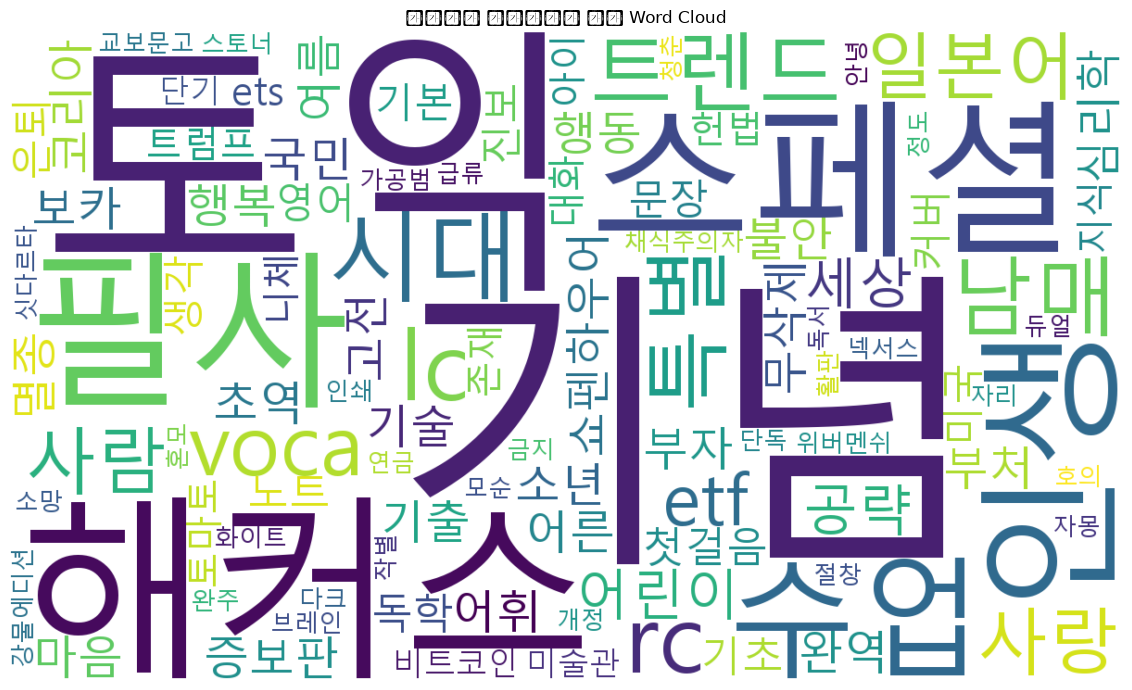

True


In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pathlib import Path

# Word Cloud 생성
wordcloud = WordCloud(
    font_path=str(FONT_PATH),
    width=1200,
    height=700,
    background_color="white",
    max_words=100,
    random_state=42,
).generate_from_frequencies(final_counter)

# 화면에 출력
plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("교보문고 베스트셀러 제목 Word Cloud")
plt.tight_layout()
plt.show()

# 이미지 파일로 저장
wordcloud.to_file("chapter02_wordcloud.png")

# 파일 생성 여부 확인
print(Path("chapter02_wordcloud.png").exists())

### 실행 결과 요약

- `final_counter`의 단어 빈도 데이터를 이용해 Word Cloud를 생성했다.
- `font_path`에 한글 폰트 경로를 지정하여 한글이 깨지지 않도록 설정했다.
- `matplotlib`를 사용해 Word Cloud 이미지를 화면에 출력했다.
- `chapter02_wordcloud.png` 파일로 저장했다.
- `Path().exists()`를 사용해 이미지 파일이 정상적으로 생성되었는지 확인했다.

### 확인 결과

- 빈도가 높은 단어일수록 더 크게 표시되는 것을 확인했다.
- 한글 단어가 정상적으로 출력되는 것을 확인했다.
- 결과 이미지가 PNG 파일로 저장된 것을 확인했다.

### 배운 점

Word Cloud는 단어 빈도 분석 결과를 한눈에 보기 쉽게 시각화하는 방법이다.

텍스트 데이터 분석에서는 표 형태 결과와 함께 Word Cloud를 사용하면  
자주 등장하는 핵심 단어를 더 직관적으로 확인할 수 있다.